# Module 10 — Unsupervised Learning: Clustering & PCA

No labels here — the algorithm finds structure on its own. This powers customer
segmentation, anomaly detection, and (your NSE project) **risk clustering of
stocks**. We'll master **K-Means** (with honest ways to pick *k*) and **PCA**
(dimensionality reduction), including the math intuition your degree will love.

Goals:
- K-Means: the algorithm, its assumptions, and failure modes.
- Choosing *k*: **elbow** + **silhouette** (the metric you improved 0.32→0.717).
- Why scaling is critical for clustering.
- PCA: variance, eigenvectors, explained variance, and when to use it.

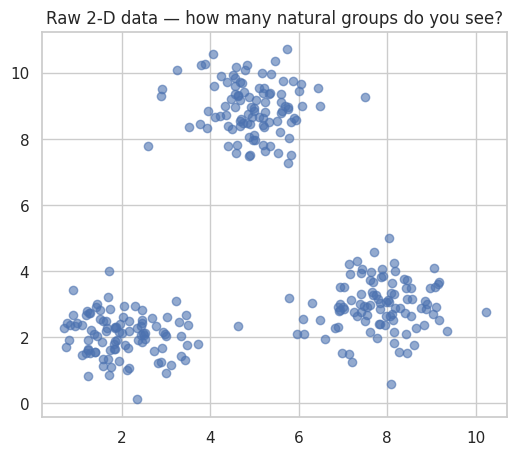

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score

sns.set_theme(style="whitegrid")
blobs = pd.read_csv("../data/blobs_2d.csv")   # we KNOW there are 3 clusters
plt.figure(figsize=(6,5))
plt.scatter(blobs["x1"], blobs["x2"], alpha=0.6)
plt.title("Raw 2-D data — how many natural groups do you see?")
plt.show()

## 10.1 K-Means — the algorithm in plain words

Goal: partition points into **k** clusters so each point is near its cluster's
**centroid** (mean). It minimizes **within-cluster sum of squares** (inertia):

$$ \text{minimize} \sum_{j=1}^{k} \sum_{x \in C_j} \| x - \mu_j \|^2 $$

Iterative recipe (Lloyd's algorithm):
1. Pick k initial centroids (k-means++ does this smartly).
2. **Assign** each point to the nearest centroid.
3. **Update** each centroid to the mean of its assigned points.
4. Repeat 2–3 until assignments stop changing.

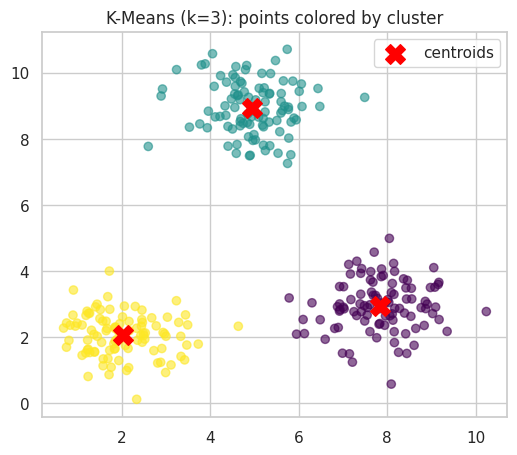

inertia (within-cluster SS): 346.1


In [2]:
X = blobs[["x1", "x2"]].values
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(X)
labels = km.labels_

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap="viridis", alpha=0.6)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            c="red", s=200, marker="X", label="centroids")
plt.title("K-Means (k=3): points colored by cluster"); plt.legend(); plt.show()
print("inertia (within-cluster SS):", round(km.inertia_, 1))

**K-Means assumptions & failure modes (say these in interviews):**
- Assumes clusters are **roughly spherical and similar size** (uses Euclidean
  distance to a mean). It struggles with elongated/odd shapes or very different
  densities → consider **DBSCAN** or **Gaussian Mixtures** there.
- Sensitive to **initialization** → use `n_init` > 1 (or k-means++).
- You must **choose k** — it won't tell you.
- **Scaling matters**: distance-based, so unscaled large-range features dominate.

## 10.2 Choosing k — the elbow method

Plot inertia vs k. Inertia always falls as k rises (more centroids = tighter
clusters), but the *rate* of improvement drops sharply at the "right" k — the
**elbow**. It's a guide, not gospel.

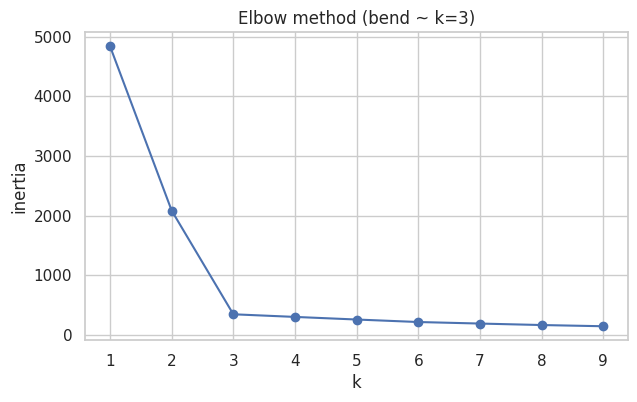

In [3]:
ks = range(1, 10)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_
            for k in ks]
plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, "o-")
plt.xlabel("k"); plt.ylabel("inertia"); plt.title("Elbow method (bend ~ k=3)")
plt.show()

## 10.3 Choosing k — the silhouette score (more rigorous)

For each point, silhouette compares how close it is to its **own** cluster vs the
**nearest other** cluster, giving a value in `[-1, 1]`:
- near **+1**: well inside its cluster (good).
- near **0**: on a boundary.
- **negative**: probably in the wrong cluster.

Average silhouette across all points scores the whole clustering. **This is the
exact metric you improved from 0.32 → 0.717 in your NSE project** — a jump from
"weak, overlapping clusters" to "clearly separated, meaningful clusters".

In [4]:
for k in range(2, 7):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    score = silhouette_score(X, km_k.labels_)
    print(f"k={k}: silhouette = {score:.3f}")
print("\nHighest silhouette => best-separated clustering (should favor k=3).")

k=2: silhouette = 0.590
k=3: silhouette = 0.775
k=4: silhouette = 0.619
k=5: silhouette = 0.497
k=6: silhouette = 0.346

Highest silhouette => best-separated clustering (should favor k=3).


### Silhouette plot — diagnose cluster quality visually

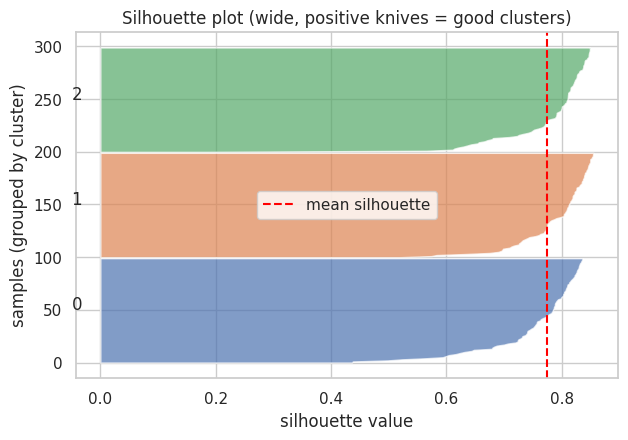

In [5]:
k = 3
km3 = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
sv = silhouette_samples(X, km3.labels_)

plt.figure(figsize=(7,4.5))
y_lower = 0
for i in range(k):
    vals = np.sort(sv[km3.labels_ == i])
    y_upper = y_lower + len(vals)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
    plt.text(-0.05, (y_lower + y_upper)/2, str(i))
    y_lower = y_upper
plt.axvline(silhouette_score(X, km3.labels_), color="red", ls="--",
            label="mean silhouette")
plt.xlabel("silhouette value"); plt.ylabel("samples (grouped by cluster)")
plt.title("Silhouette plot (wide, positive knives = good clusters)")
plt.legend(); plt.show()

## 10.4 The scaling lesson for clustering (real customer data)

Let's cluster our customers by `income` and `support_calls`. Income is in the tens
of thousands; calls are 0–6. **Without scaling**, K-Means "sees" only income and
ignores calls entirely. Scaling fixes it.

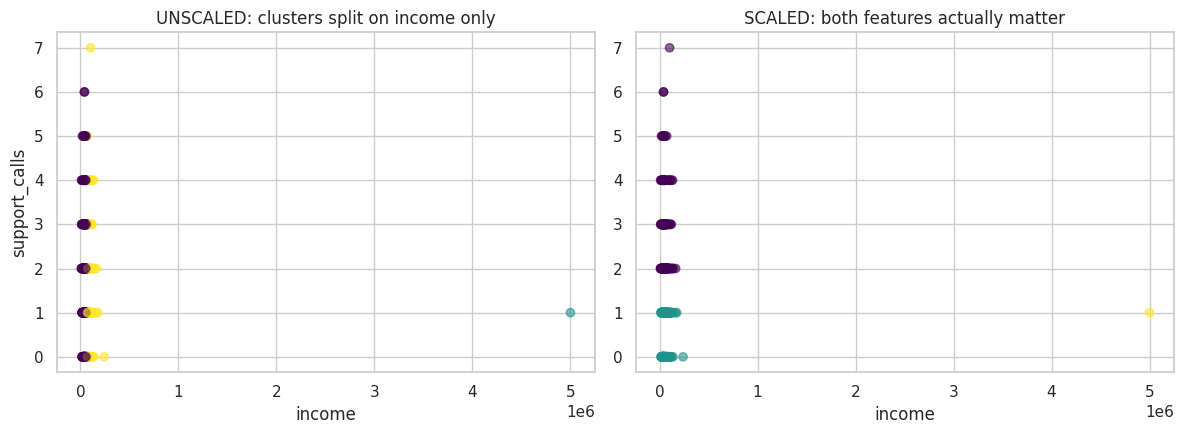

Unscaled silhouette: 0.624 | Scaled silhouette: 0.627


In [6]:
cust = pd.read_csv("../data/customers_clean.csv")
feat = cust[["income", "support_calls"]].dropna().values

# unscaled
lab_raw = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(feat)
# scaled
feat_s = StandardScaler().fit_transform(feat)
lab_scaled = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(feat_s)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(feat[:,0], feat[:,1], c=lab_raw, cmap="viridis", alpha=0.6)
ax[0].set_title("UNSCALED: clusters split on income only"); ax[0].set_xlabel("income"); ax[0].set_ylabel("support_calls")
ax[1].scatter(feat[:,0], feat[:,1], c=lab_scaled, cmap="viridis", alpha=0.6)
ax[1].set_title("SCALED: both features actually matter"); ax[1].set_xlabel("income")
plt.tight_layout(); plt.show()
print("Unscaled silhouette:", round(silhouette_score(feat, lab_raw), 3),
      "| Scaled silhouette:", round(silhouette_score(feat_s, lab_scaled), 3))

## 10.4b Hierarchical (Agglomerative) clustering — no need to pre-pick k

K-Means demands you choose *k* up front. **Agglomerative** clustering builds a
**tree (dendrogram)** instead: start with every point as its own cluster, then
repeatedly **merge the two closest clusters** until one remains. You then "cut" the
tree at whatever height gives the number of clusters you want.

**"Closest" depends on the `linkage`:**
- `ward` — merge the pair that increases total within-cluster variance least
  (default; gives compact, K-Means-like clusters). **Best general choice.**
- `complete` — distance = farthest pair (tight, sensitive to outliers).
- `average` — distance = average pairwise.
- `single` — distance = nearest pair (can "chain" — good for non-globular, but
  noisy).

**Why use it:** no k needed up front, the dendrogram *shows* the cluster structure,
and it handles non-spherical shapes better than K-Means. Downside: O(n²) memory —
slow for very large n.

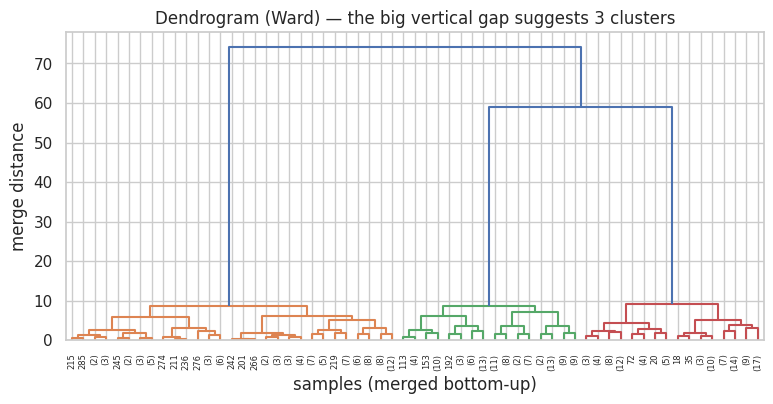

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Build the linkage matrix (Ward) and draw the dendrogram.
Z = linkage(X, method="ward")
plt.figure(figsize=(9, 4))
dendrogram(Z, truncate_mode="level", p=5, color_threshold=0.7*max(Z[:,2]))
plt.title("Dendrogram (Ward) — the big vertical gap suggests 3 clusters")
plt.xlabel("samples (merged bottom-up)"); plt.ylabel("merge distance")
plt.show()

**Reading a dendrogram:** the y-axis is the distance at which clusters merge. Find
the **tallest vertical gap** that no horizontal line crosses — cutting there gives
the natural number of clusters. Here the largest jump splits the data into **3**,
matching what K-Means found.

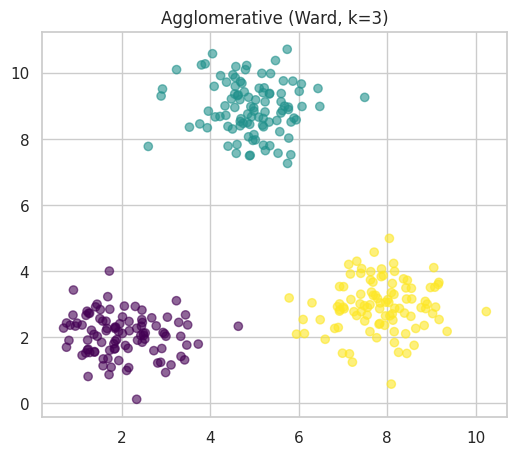

Agglomerative silhouette: 0.775


In [8]:
agg = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(X)
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=agg.labels_, cmap="viridis", alpha=0.6)
plt.title("Agglomerative (Ward, k=3)")
plt.show()
print("Agglomerative silhouette:", round(silhouette_score(X, agg.labels_), 3))

## 10.4c DBSCAN — density-based, finds arbitrary shapes & flags noise

DBSCAN groups points that are **densely packed** and labels sparse points as
**noise (−1)**. It shines exactly where K-Means fails: non-spherical clusters
(rings, moons), and it does **not** need k — it discovers the number of clusters.

**Two parameters:**
- `eps` — neighborhood radius: how close is "close".
- `min_samples` — how many neighbors within `eps` make a point a dense "core".

A point is: **core** (≥ min_samples neighbors), **border** (near a core), or
**noise** (neither). Watch it separate two moons that K-Means cannot:

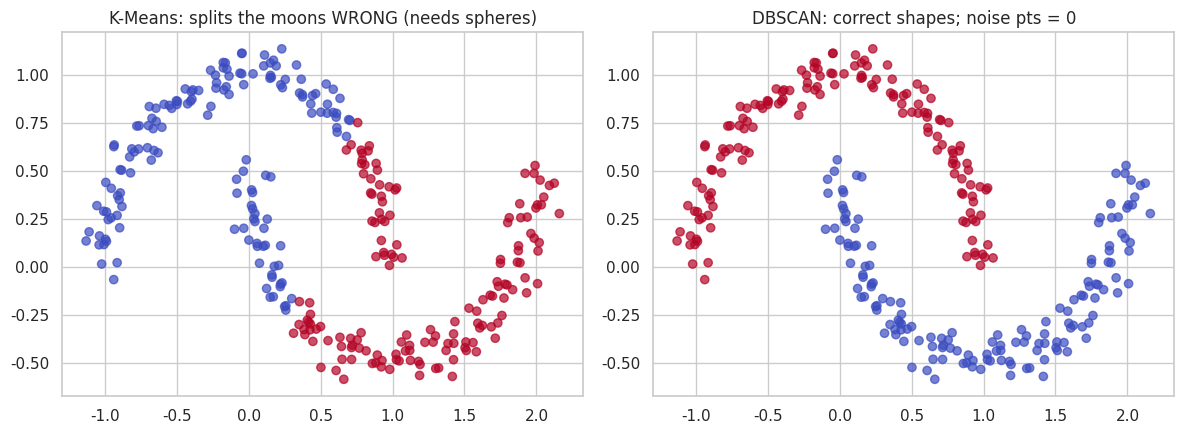

In [9]:
from sklearn.datasets import make_moons
Xm, _ = make_moons(n_samples=300, noise=0.06, random_state=42)

km_m  = KMeans(n_clusters=2, n_init=10, random_state=42).fit_predict(Xm)
db_m  = DBSCAN(eps=0.20, min_samples=5).fit_predict(Xm)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(Xm[:,0], Xm[:,1], c=km_m, cmap="coolwarm", alpha=0.7)
ax[0].set_title("K-Means: splits the moons WRONG (needs spheres)")
ax[1].scatter(Xm[:,0], Xm[:,1], c=db_m, cmap="coolwarm", alpha=0.7)
ax[1].set_title(f"DBSCAN: correct shapes; noise pts = {(db_m==-1).sum()}")
plt.tight_layout(); plt.show()

**When to reach for DBSCAN:** arbitrary shapes, unknown number of clusters, and
you want automatic **outlier/noise detection** (label −1). Downsides: very
sensitive to `eps`/`min_samples`, and it struggles when clusters have very
different densities. **Always scale first** (it's distance-based).

## 10.4d Gaussian Mixture Models (GMM) — soft, elliptical clusters

K-Means gives **hard** assignments (a point belongs to exactly one cluster) and
assumes round blobs. A **GMM** models the data as a mix of Gaussian "bells" and
gives each point a **probability** of belonging to each cluster (**soft**
assignment). Because each Gaussian has its own covariance, clusters can be
**stretched/rotated ellipses**, not just circles.

- Fit via **Expectation-Maximization (EM)**: E-step assigns soft
  responsibilities, M-step re-estimates each Gaussian's mean/covariance. Repeat.
- Choose the number of components with **BIC/AIC** (lower = better) — an
  information-criterion analogue to the elbow.

example soft memberships (first 3 points):
[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]

BIC by n_components: [2965, 2491, 2118, 2150, 2179, 2202] -> best = 3


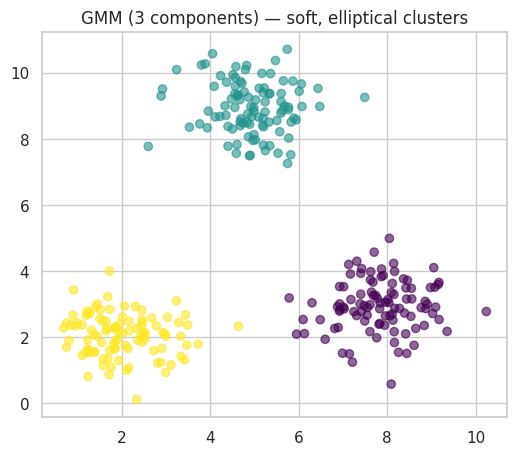

In [10]:
gmm = GaussianMixture(n_components=3, covariance_type="full",
                      random_state=42).fit(X)
proba = gmm.predict_proba(X)          # soft memberships (rows sum to 1)
hard  = gmm.predict(X)

print("example soft memberships (first 3 points):")
print(np.round(proba[:3], 3))

# Model selection by BIC:
bics = [GaussianMixture(n, covariance_type="full", random_state=42).fit(X).bic(X)
        for n in range(1, 7)]
print("\nBIC by n_components:", [round(b) for b in bics],
      "-> best =", int(np.argmin(bics)) + 1)

plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=hard, cmap="viridis", alpha=0.6)
plt.title("GMM (3 components) — soft, elliptical clusters"); plt.show()

**K-Means vs GMM in one line:** K-Means is a *special case* of GMM with spherical,
equal covariances and hard assignments. Use **GMM** when clusters overlap or are
elliptical, or when you need a **probability** (e.g. "80% likely high-risk").

### Clustering algorithm cheat-sheet
| Algorithm | Needs k? | Cluster shape | Gives probabilities? | Detects noise? |
|---|---|---|---|---|
| **K-Means** | yes | spherical, equal size | no (hard) | no |
| **Agglomerative** | cut the tree | flexible (linkage) | no | no |
| **DBSCAN** | no | **arbitrary** | no | **yes (−1)** |
| **GMM** | yes (n_components) | **elliptical** | **yes (soft)** | no |

## 10.5 PCA — Principal Component Analysis

PCA finds new axes (**principal components**) that are (1) orthogonal and (2)
ordered by how much **variance** they capture. PC1 is the direction of maximum
spread; PC2 the next, perpendicular to PC1; and so on. Mathematically they are the
**eigenvectors of the covariance matrix**, and each component's captured variance
is its **eigenvalue** — right in your linear-algebra wheelhouse.

Uses:
- **Dimensionality reduction**: keep the few components that hold most variance →
  less noise, faster models, fights the curse of dimensionality.
- **Visualization**: project high-dim data to 2-D.
- **Decorrelation**: components are uncorrelated.

**Always scale before PCA** — it's variance-based, so unscaled big features hijack
the components.

explained variance ratio per PC: [0.73  0.229 0.037 0.005]
cumulative: [0.73  0.958 0.995 1.   ]


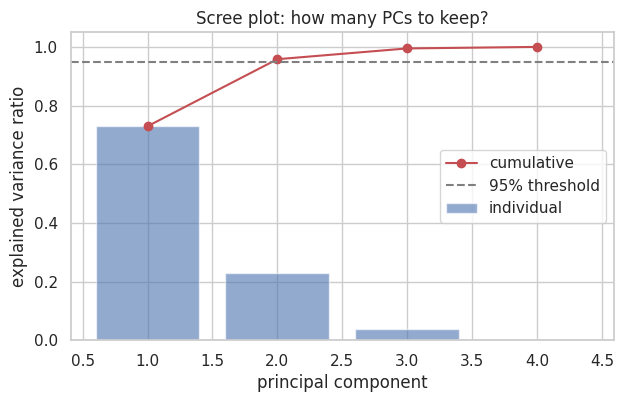

In [11]:
from sklearn.datasets import load_iris
iris = load_iris()
Xi = StandardScaler().fit_transform(iris.data)   # 4 features -> scaled

pca = PCA().fit(Xi)
ev = pca.explained_variance_ratio_
print("explained variance ratio per PC:", ev.round(3))
print("cumulative:", ev.cumsum().round(3))

plt.figure(figsize=(7,4))
plt.bar(range(1, len(ev)+1), ev, alpha=0.6, label="individual")
plt.plot(range(1, len(ev)+1), ev.cumsum(), "ro-", label="cumulative")
plt.axhline(0.95, color="gray", ls="--", label="95% threshold")
plt.xlabel("principal component"); plt.ylabel("explained variance ratio")
plt.title("Scree plot: how many PCs to keep?"); plt.legend(); plt.show()

**Reading it:** if the first 2 components already explain ~95% of variance, we can
compress 4 features → 2 with almost no information loss. That's the essence of
dimensionality reduction. The rule of thumb: keep enough PCs to reach a target
cumulative variance (e.g. 90–95%).

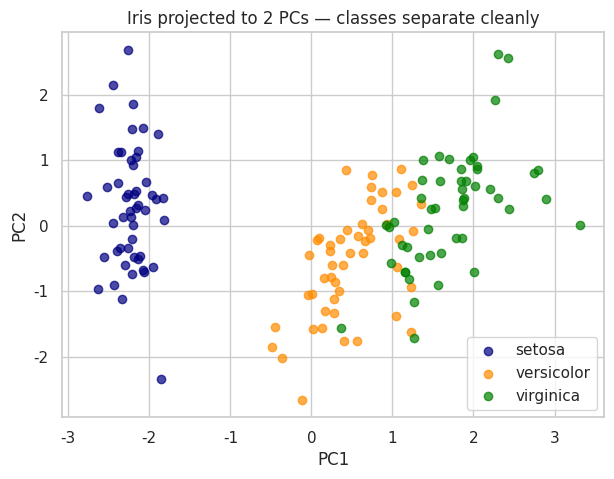

In [12]:
proj = PCA(n_components=2).fit_transform(Xi)
plt.figure(figsize=(7,5))
for cls, name, c in zip(range(3), iris.target_names, ["navy","darkorange","green"]):
    m = iris.target == cls
    plt.scatter(proj[m,0], proj[m,1], label=name, alpha=0.7, color=c)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("Iris projected to 2 PCs — classes separate cleanly"); plt.legend()
plt.show()

**Caveat to mention:** PCA components are **linear combinations** of original
features, so they're less interpretable ("PC1 = 0.5·petal_len + 0.4·petal_wid…").
Use PCA when compression/denoising/visualization matters more than per-feature
interpretability.

## 10.5b LDA vs PCA — the two dimensionality-reduction cousins

**PCA is unsupervised**: it finds axes of maximum *variance*, ignoring labels.
**Linear Discriminant Analysis (LDA)** is **supervised**: it finds axes that
maximize *class separation* — the direction that pushes class means apart while
keeping each class tight. When your goal is classification, LDA's projection is
often more useful than PCA's.

- PCA maximizes: total variance.
- LDA maximizes: between-class scatter ÷ within-class scatter (the Fisher criterion).
- LDA can produce **at most (n_classes − 1)** components (3 iris classes → 2 LDA axes).

LDA is *also* a full **classifier** (it fits a Gaussian per class with a shared
covariance → linear decision boundaries). Two tools in one.

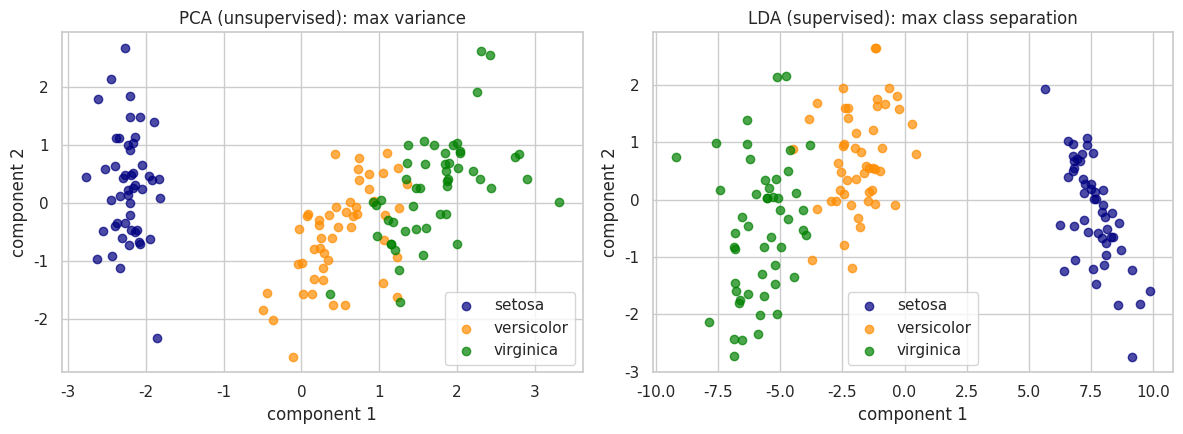

LDA classification accuracy (5-fold): 0.98


In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
proj_lda = lda.fit_transform(Xi, iris.target)   # NOTE: uses labels (supervised)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
for cls, name, c in zip(range(3), iris.target_names, ["navy","darkorange","green"]):
    m = iris.target == cls
    ax[0].scatter(proj[m,0],     proj[m,1],     label=name, alpha=0.7, color=c)
    ax[1].scatter(proj_lda[m,0], proj_lda[m,1], label=name, alpha=0.7, color=c)
ax[0].set_title("PCA (unsupervised): max variance")
ax[1].set_title("LDA (supervised): max class separation")
for a in ax: a.set_xlabel("component 1"); a.set_ylabel("component 2"); a.legend()
plt.tight_layout(); plt.show()

# LDA as a classifier too:
print("LDA classification accuracy (5-fold):",
      round(cross_val_score(LinearDiscriminantAnalysis(), Xi, iris.target, cv=5).mean(), 3))

**When to use which:** unlabeled data or general compression/denoising → **PCA**.
Labeled data where the downstream task is classification → try **LDA** (it uses the
labels to separate classes better, and doubles as a fast linear classifier).

## 10.6 Mini-exercises

1. Cluster the customers on 4 scaled features; pick k by silhouette; then *profile*
   each cluster (mean of each feature) and give each a business name.
2. Run PCA on those 4 features; how many PCs for 90% variance?
3. Reduce to 2 PCs, then K-Means on the projection — does silhouette improve?
4. Explain why K-Means might fail on two concentric rings, and what you'd use
   instead.

## Summary

- **K-Means** minimizes within-cluster variance; assumes spherical, similar-size
  clusters; needs **scaling** and a chosen **k**.
- Choose k with the **elbow** (inertia bend) and, more rigorously, the
  **silhouette** score — the metric behind your NSE 0.32→0.717 win.
- **Agglomerative/hierarchical** builds a **dendrogram** (cut it to pick k; `ward`
  is the go-to linkage). **DBSCAN** finds **arbitrary shapes** + **noise** without k.
  **GMM** gives **soft, elliptical** clusters with membership probabilities (choose
  components by BIC). Match the algorithm to the cluster *shape*.
- **PCA** re-expresses data along max-variance orthogonal axes (eigenvectors of
  covariance); keep top PCs for compression/denoising/plots. **Scale first.**
- Trade interpretability for compactness knowingly.

Next: **Module 11 — Neural Networks intro**.